1. Diagnóstico del Ecosistema Digital (Olist)
Este proyecto integra los tres pilares de una empresa moderna: E-commerce, Fintech y Logística. El objetivo es identificar ineficiencias y proponer mejoras tecnológicas basadas en datos.
Dataset: 100,000 pedidos reales de Olist (Brasil).
Meta: Optimizar la experiencia del usuario y la rentabilidad.

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

def configurar_estilo_profesional():
    # 1. Volver al estilo claro, limpio y moderno
    sns.set_theme(style="white") 
    
    # 2. Configuración detallada para que no se vea "por defecto"
    plt.rcParams.update({
        "figure.facecolor": "white",      # Fondo de la imagen blanco puro
        "axes.facecolor": "white",        # Fondo de la gráfica blanco
        "axes.edgecolor": "#D1D1D1",      # Bordes gris muy claro
        "grid.color": "#F0F0F0",          # Rejilla casi invisible
        "text.color": "#333333",          # Texto gris oscuro (más legible que negro)
        "axes.labelcolor": "#555555",     # Etiquetas suaves
        "font.family": "sans-serif",      # Fuente moderna
        "font.sans-serif": ["Arial", "DejaVu Sans"]
    })
    print("✨ Estilo Profesional Minimalista Activado")

configurar_estilo_profesional()



✨ Estilo Profesional Minimalista Activado


In [35]:
import pandas as pd

# 1. Cargar el dataset
df = pd.read_csv('olist_data.csv') 

# 2. Ver las columnas para identificar qué pertenece a cada sector
print("Columnas encontradas:")
print(df.columns.tolist())

# 3. Vista rápida de los datos
df.head()

Columnas encontradas:
['Unnamed: 0', 'order_id', 'order_item_id', 'customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_id', 'seller_city', 'seller_state', 'seller_zip_code_prefix', 'payment_type', 'payment_sequential', 'payment_installments', 'price', 'freight_value', 'payment_value', 'shipping_limit_date', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'day_of_purchase', 'month_of_purchase', 'year_of_purchase', 'month/year_of_purchase', 'order_status', 'order_unique_id']


,Unnamed: 0,order_id,order_item_id,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,product_category_name,...,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,day_of_purchase,month_of_purchase,year_of_purchase,month/year_of_purchase,order_status,order_unique_id
0,0,00010242fe8c5a6d1ba2dd792cb16214,1,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,Wednesday,September,2017,September-2017,delivered,00010242fe8c5a6d1ba2dd792cb16214-1
1,1,130898c0987d1801452a8ed92a670612,1,e6eecc5a77de221464d1c4eaff0a9b64,0fb8e3eab2d3e79d92bb3fffbb97f188,75800,jatai,GO,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-06-29 02:44:11,2017-07-05 12:00:33,2017-07-13 20:39:29,2017-07-26 00:00:00,Wednesday,June,2017,June-2017,delivered,130898c0987d1801452a8ed92a670612-1
2,2,532ed5e14e24ae1f0d735b91524b98b9,1,4ef55bf80f711b372afebcb7c715344a,3419052c8c6b45daf79c1e426f9e9bcb,30720,belo horizonte,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2018-05-18 12:31:43,2018-05-23 14:05:00,2018-06-04 18:34:26,2018-06-07 00:00:00,Friday,May,2018,May-2018,delivered,532ed5e14e24ae1f0d735b91524b98b9-1
3,3,6f8c31653edb8c83e1a739408b5ff750,1,30407a72ad8b3f4df4d15369126b20c9,e7c828d22c0682c1565252deefbe334d,83070,sao jose dos pinhais,PR,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-08-01 18:55:08,2017-08-02 19:07:36,2017-08-09 21:26:33,2017-08-25 00:00:00,Tuesday,August,2017,August-2017,delivered,6f8c31653edb8c83e1a739408b5ff750-1
4,4,7d19f4ef4d04461989632411b7e588b9,1,91a792fef70ecd8cc69d3c7feb3d12da,0bb98ba72dcc08e95f9d8cc434e9a2cc,36400,conselheiro lafaiete,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-08-10 22:05:11,2017-08-11 19:43:07,2017-08-24 20:04:21,2017-09-01 00:00:00,Thursday,August,2017,August-2017,delivered,7d19f4ef4d04461989632411b7e588b9-1


2. Capa Fintech: Comportamiento de Pago y Liquidez
Analizamos los métodos de pago para entender la salud financiera de la plataforma. El uso de Boleto (pago en efectivo) es un reto tecnológico, ya que retrasa la validación de la compra y, por ende, la logística.

--- Métodos de Pago más usados ---
payment_type
credit_card    83706
boleto         22047
voucher         6012
debit_card      1625
Name: count, dtype: int64

El gasto promedio por pedido es: R$ 172.24


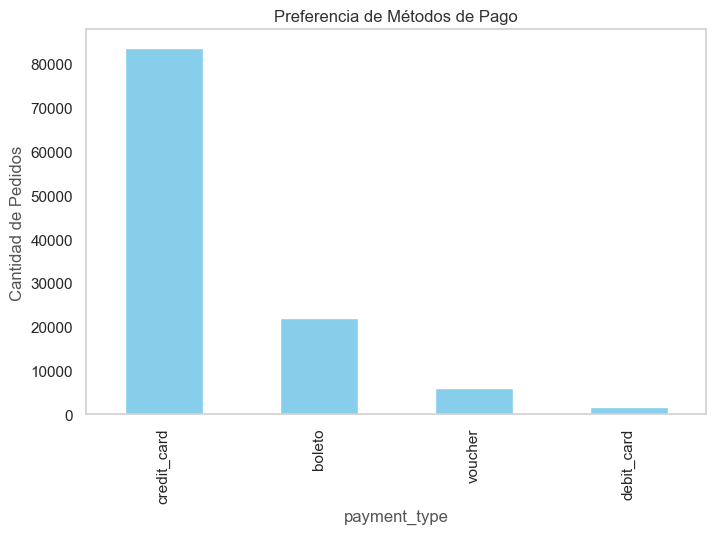

In [36]:
# 1. ¿Cómo prefiere pagar el cliente brasileño?
pagos_resumen = df['payment_type'].value_counts()
print("--- Métodos de Pago más usados ---")
print(pagos_resumen)

# 2. ¿Cuál es el ticket promedio (gasto por pedido)?
ticket_promedio = df['payment_value'].mean()
print(f"\nEl gasto promedio por pedido es: R$ {ticket_promedio:.2f}")

# 3. Visualización rápida (Para tu portafolio)
import matplotlib.pyplot as plt

pagos_resumen.plot(kind='bar', color='skyblue', figsize=(8,5))
plt.title('Preferencia de Métodos de Pago')
plt.ylabel('Cantidad de Pedidos')
plt.show()


3. Capa Logística: Eficiencia en la Entrega (Mejora de Procesos)
La promesa de entrega es el factor #1 de retención de clientes. Aquí calculamos la brecha entre los días prometidos y los días reales. Un retraso alto impacta directamente en el soporte al cliente y en las reseñas de la app.

In [37]:
# 1. Convertir las columnas de fechas a formato tiempo (Data Cleaning profesional)
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

# 2. Calcular los días reales vs. los estimados (Logística)
# Tiempo real que tardó en llegar
df['dias_reales'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# Tiempo que la empresa PROMETIÓ
df['dias_prometidos'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days

# 3. ¿Cuántos pedidos llegaron TARDE? (Mejora de Procesos)
pedidos_tarde = df[df['order_delivered_customer_date'] > df['order_estimated_delivery_date']]
porcentaje_tarde = (len(pedidos_tarde) / len(df)) * 100

print(f"--- Desempeño Logístico ---")
print(f"Días promedio de entrega: {df['dias_reales'].mean():.1f} días")
print(f"Porcentaje de pedidos con RETRASO: {porcentaje_tarde:.2f}%")


--- Desempeño Logístico ---
Días promedio de entrega: 12.0 días
Porcentaje de pedidos con RETRASO: 7.83%


4. Intersección de Sectores: ¿Influye el Pago en la Entrega?
Hipótesis: Los pagos con Boleto tardan más en procesarse que las tarjetas de crédito, lo que podría retrasar la salida del paquete del almacén y aumentar el riesgo de entrega tardía.

--- Porcentaje de Retraso por Método de Pago ---
payment_type
boleto         8.577131
debit_card     8.000000
credit_card    7.728239
voucher        6.420492
Name: llego_tarde, dtype: float64


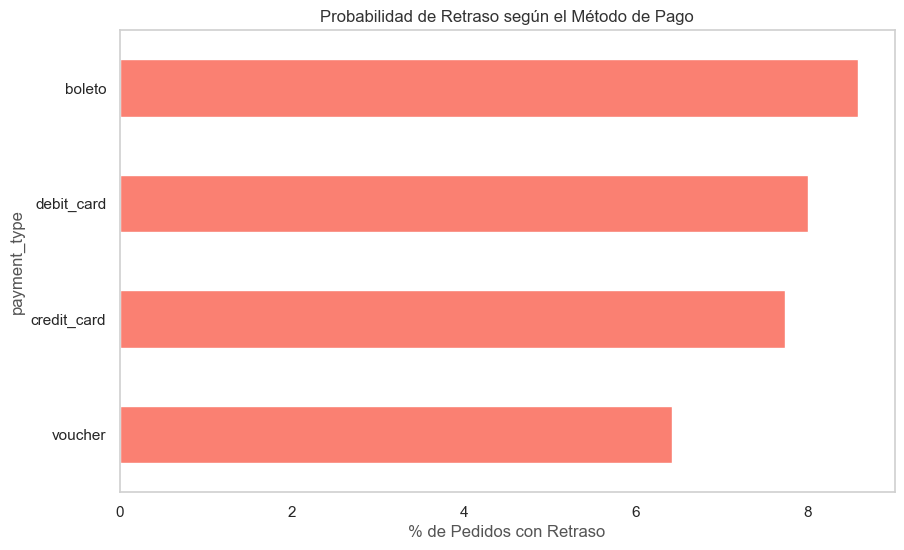

In [38]:
# 1. Creamos una columna binaria: 1 si llegó tarde, 0 si llegó a tiempo
df['llego_tarde'] = (df['order_delivered_customer_date'] > df['order_estimated_delivery_date']).astype(int)

# 2. Agrupamos por tipo de pago para ver el % de retraso en cada uno
retraso_por_pago = df.groupby('payment_type')['llego_tarde'].mean() * 100

print("--- Porcentaje de Retraso por Método de Pago ---")
print(retraso_por_pago.sort_values(ascending=False))

# 3. Visualización para el Portafolio
retraso_por_pago.sort_values().plot(kind='barh', color='salmon', figsize=(10,6))
plt.title('Probabilidad de Retraso según el Método de Pago')
plt.xlabel('% de Pedidos con Retraso')
plt.show()


5. Categorías Críticas: ¿En qué productos el retraso es más grave?
Analizamos el impacto logístico por categoría de producto. No es lo mismo un retraso en un "Adorno de Navidad" que en una "Computadora" o "Salud". Identificar estas categorías permite priorizar envíos de alto valor o urgencia.

--- TOP 10 Categorías con Mayor % de Retrasos ---
product_category_name
casa_conforto_2                      16.129032
moveis_colchao_e_estofado            12.500000
audio                                12.433862
artigos_de_natal                     11.842105
fashion_underwear_e_moda_praia       11.428571
livros_tecnicos                      10.902256
construcao_ferramentas_iluminacao    10.322581
eletronicos                           9.796936
alimentos                             9.708738
casa_conforto                         9.361702
Name: llego_tarde, dtype: float64


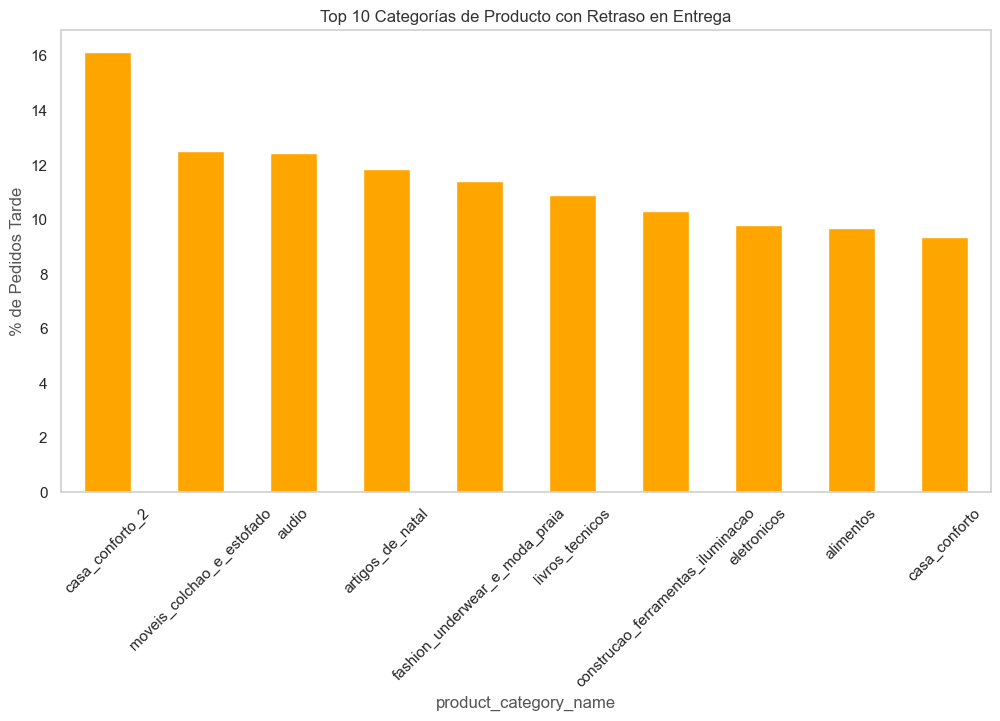

In [39]:
# 1. Agrupamos por categoría de producto para ver el % de retraso
retraso_por_categoria = df.groupby('product_category_name')['llego_tarde'].mean() * 100

# 2. Mostramos las 10 categorías que más problemas de logística tienen
top_retrasos = retraso_por_categoria.sort_values(ascending=False).head(10)

print("--- TOP 10 Categorías con Mayor % de Retrasos ---")
print(top_retrasos)

# 3. Visualización de Impacto
top_retrasos.plot(kind='bar', color='orange', figsize=(12,6))
plt.title('Top 10 Categorías de Producto con Retraso en Entrega')
plt.ylabel('% de Pedidos Tarde')
plt.xticks(rotation=45)
plt.show()


In [40]:
# Guardamos el archivo final procesado para llevarlo a Power BI
df.to_csv('olist_analisis_final.csv', index=False)
print("¡Archivo 'olist_analisis_final.csv' listo para el Dashboard!")


¡Archivo 'olist_analisis_final.csv' listo para el Dashboard!
